# Polynomial Regression with NumPy

## Data

In [1]:
from IPython.core.display import display, HTML
import matplotlib.pyplot as plt
import more_itertools
import numpy
import typing

# The random seed is fixed in order to have reproducible results
numpy.random.seed(2020)

# Generation of 100000 random numbers distributed according to 
# the normal distribution X ~ N(5, 1) 
x = numpy.random.normal(5, 1.0, 100000)

# Generating our targets, Gaussian noise divided by x².
# y = numpy.random.normal(50.0, 10.0, 100000) / x ** 2
y = numpy.random.normal(50.0, 10.0, 100000) / x + x ** 2

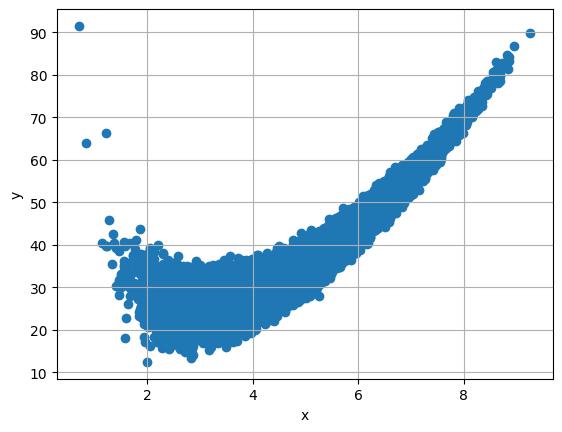

In [2]:
axes = plt.axes()
axes.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(x, y)
plt.show()

## Defining a function to represent a polynomial

Takes a polynomial (of type `numpy.poly1D`) and displays it.

In [3]:
def power_to_html(power: int, coeff: float) -> typing.Tuple[str, bool]:
  str_out = f"{abs(coeff):.3f}"
  if power >= 1:
    str_out += "𝑥"
    if power > 1:
      str_out += f"<sup>{power}</sup>"
  return str_out, coeff >= 0

def display_poly_equation(poly: numpy.poly1d) -> str:
  html_strs, positives = zip(*(power_to_html(poly.order - i, c)
                             for i, c in enumerate(poly.coefficients)))
  joins = [" + " if sign else " - " for sign in positives[1:]]
  terms = "".join(more_itertools.interleave_longest(html_strs, joins))
  display(HTML(f"𝑦 = {terms}"))

## Model Training

In [4]:
def fit_poly(x: numpy.ndarray, y: numpy.ndarray, d: int) -> numpy.poly1d:
  # numpy.polyfit finds the optimal parameters of a polynomial of degree d
  # such that y = poly(x)
  params = numpy.polyfit(x, y, d)

  # Defines an object of type numpy.poly1d from the learned parameters
  return numpy.poly1d(params)

poly = fit_poly(x, y, 2)
poly

poly1d([ 1.52093346, -7.5211607 , 34.51770933])

## Final display

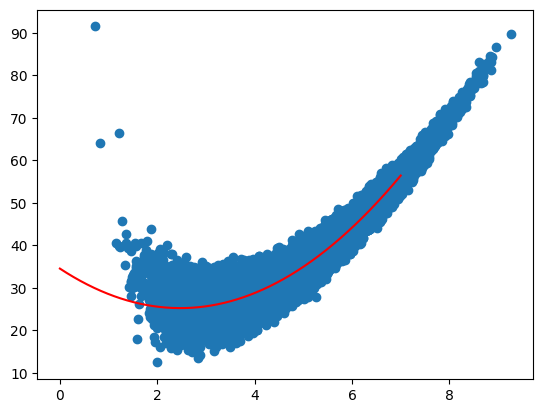

In [5]:
def display_poly(poly: numpy.poly1d) -> None:
  # Display a human readable polynome
  display_poly_equation(poly)

  # Compute the learned function on several points
  preds_x = numpy.linspace(0, 7, 1000)
  preds_y = poly(preds_x)

  # Display predicted data
  plt.plot(preds_x, poly(preds_x), c='r')

  # Display raw data
  plt.scatter(x, y)

  plt.show()


display_poly(poly)

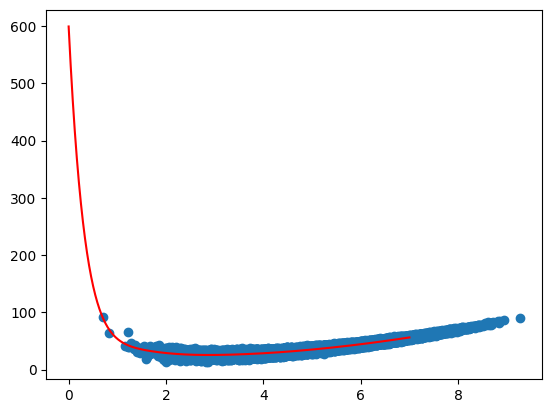

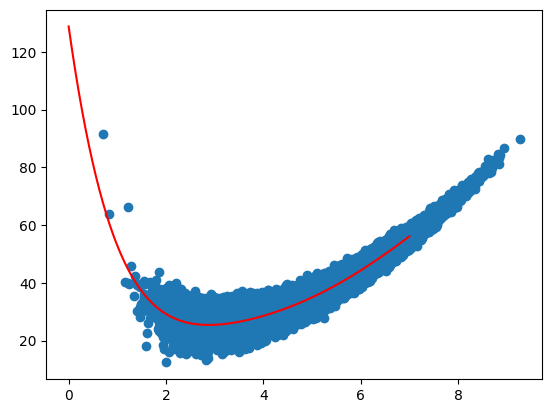

In [6]:
def fit_and_display_poly(x: numpy.ndarray, y: numpy.ndarray, d: int) -> None:
  poly = fit_poly(x, y, d)
  display_poly(poly)

fit_and_display_poly(x, y, 12)
fit_and_display_poly(x, y, 6)